In this notebook we show that tensor decoupling can be used with more complex functions than low-degree polynomials.

Let's define a periodic multivariate function.

In [8]:
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme('notebook', 'white', palette='dark')

key = jax.random.key(0)

def target(x):
    x1, x2 = x
    return jnp.array([
        jnp.cos(3*jnp.pi*x1) + jnp.cos(jnp.pi*x2),
        2*jnp.sin(2*jnp.pi*x2) - jnp.sin(jnp.pi*x1),
    ])

We can plot each output for $x_1 = x_2$, to get an idea of the shape of this function.

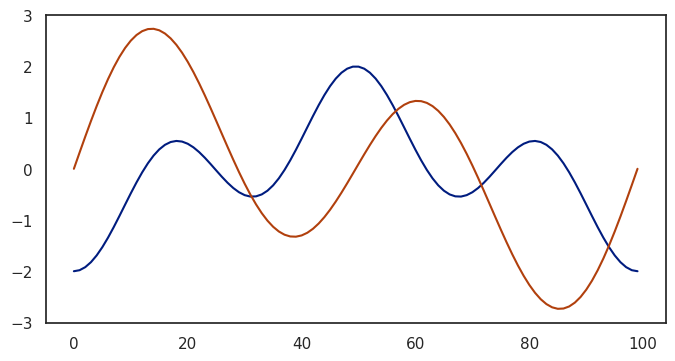

In [9]:
x = jnp.linspace(-1, 1, 100)
x = jnp.stack([x, x], axis=1)
Y = jax.vmap(target)(x)

plt.figure(figsize=(8, 4))
plt.plot(Y[:, 0])
plt.plot(Y[:, 1])
plt.show(); plt.close()

In [10]:
from untangle.utils import collect_information

N = 100
info = collect_information(target, N, key, minval=-1.0, maxval=1.0)
info[2].shape

(2, 2, 100)

However, instead of the `basic_decoupling` algorithm used in the previous notebook, we will use a more powerful, B-spline-based algorithm called CMTF-BSD (from [this paper](https://arxiv.org/abs/2504.03263)).

In [11]:
from untangle.algorithm import cmtf_bsd

rank = 4
decoupling, error = cmtf_bsd(*info, rank, key=key)
print(f'Error: {error:.4f}')

|CMTF-BSD| (rank=4): 100%|██████████████████████████████████| 100/100 [00:00<00:00, 123.80it/s, error=0.0170, best=0.0163 (18)]

Error: 0.0163


In [12]:
from untangle.utils import function_error
function_error(target, decoupling, info[0])

Array([6.8952665, 0.2873306], dtype=float32)

Both tensor and functions errors are quite low, indicating that our method managed to find a decent approximation of the target.
Lets plot the outputs to see if they match.

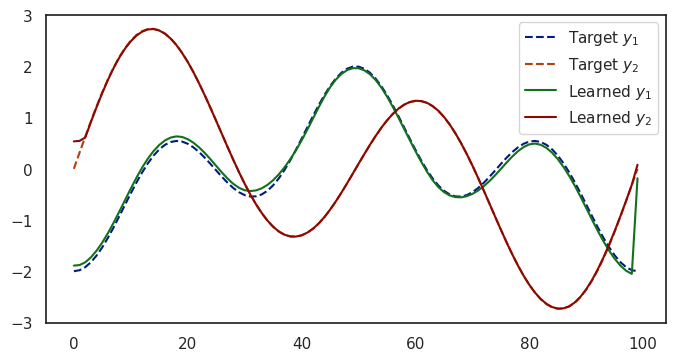

In [13]:
Y = jax.vmap(target)(x)
Y_ = jax.vmap(decoupling)(x)

plt.figure(figsize=(8, 4))
plt.plot(Y[:, 0], label='Target $y_1$', linestyle='--')
plt.plot(Y[:, 1], label='Target $y_2$', linestyle='--')
plt.plot(Y_[:, 0], label='Learned $y_1$')
plt.plot(Y_[:, 1], label='Learned $y_2$')
plt.legend(); plt.show(); plt.close()

That looks very good, the curves overlap almost perfectly!

Again, to get some insights about our target, we can look at the shapes of the internals of the returned decoupled model.

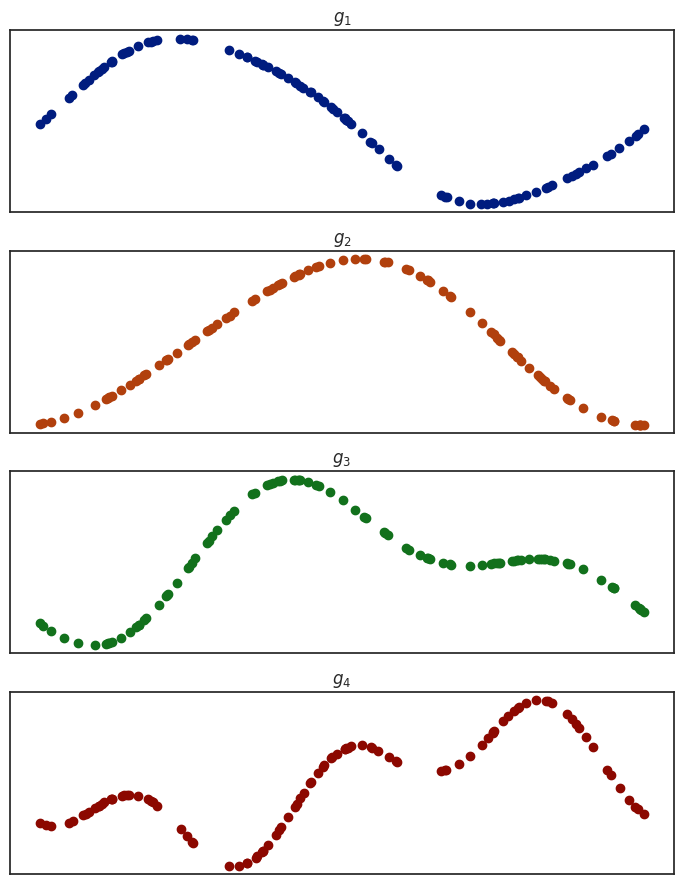

In [14]:
colors = sns.color_palette()

Z = info[0] @ decoupling.V
O = []

for z in Z:
    o = decoupling.internals(z)
    O.append(o)

O = jnp.stack(O)

fig, ax = plt.subplots(rank, figsize=(7, 9))
for i, a in enumerate(ax): 
    a.set_xticks([]); a.set_yticks([])
    a.scatter(Z[:, i], O[:, i], color=colors[i])
    a.set_title(f'$g_{i+1}$')

plt.tight_layout(); plt.show()